# 04 — Fine-tune con corrupciones vs DeMemte VQSA

Comparación entre un ResNet18 fine-tuneado con corrupciones y DeMemte VQSA con backbone congelado.

In [9]:
import sys, os
from pathlib import Path
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'src' / 'dememte').exists():
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
print('repo root:', ROOT)

repo root: /home/nakato/projects/Dememte


In [10]:
import json
from dataclasses import asdict

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from dememte.config import BaselineConfig, E5Config, resolve_data_dir
from dememte.data import build_loaders, seed_everything
from dememte.models import ResNetBaseline, make_dememte_e5
from dememte.training import train_baseline_phased, train_dememte_vqsa
from dememte.evaluation import evaluate_baseline_suite, evaluate_dememte_suite, signal_curve_rows, signal_curve_rows_baseline
from dememte.io import load_checkpoint, save_checkpoint, write_json, write_csv, ensure_dir

device = 'cuda' if torch.cuda.is_available() else 'cpu'
OUT = ensure_dir(ROOT / 'notebooks' / '04_finetune_vs_frozen' / 'out')
RUN_TRAINING = True
FT_CKPT = OUT / 'resnet18_ft_corrupt.pt'
VQSA_CKPT = ROOT / 'notebooks' / '02_e5_winner' / 'out' / 'vqsa_best.pt'
seed_everything(42)

## Datos

In [11]:
data_dir = resolve_data_dir(BaselineConfig())
tr_loader, va_loader, te_loader, meta = build_loaders(
    data_dir=data_dir,
    batch_size=16,
    num_workers=2,
    val_ratio=0.2,
    split_seed=42,
    protocol='historical_trainval_resplit',
)
print(meta)

{'protocol': 'historical_trainval_resplit', 'split_seed': 42, 'train_size': 1632, 'val_size': 408, 'test_size': 6149}


## Condición A — ResNet18 fine-tune completo con corrupciones agresivas

In [12]:
ft_cfg = BaselineConfig(freeze_backbone=False)
ft_cfg.data_dir = data_dir
ft_cfg.train_corrupt_prob = 0.85  # aug agresivo para empujar robustez
ft_cfg.backbone_lr = 1e-4
ft_cfg.epochs_warmup = 2
ft_cfg.epochs_corrupt = 8
ft_cfg.epochs_joint = 12
print(json.dumps(asdict(ft_cfg), indent=2))

ft_model = ResNetBaseline(num_classes=ft_cfg.num_classes, freeze_backbone=False).to(device)
if RUN_TRAINING:
    ft_model, ft_best = train_baseline_phased(ft_model, tr_loader, va_loader, ft_cfg, device)
    save_checkpoint(ft_model, FT_CKPT, extra={'best_val': ft_best, 'config': asdict(ft_cfg)})
elif FT_CKPT.exists():
    payload = load_checkpoint(ft_model, FT_CKPT, device=device, strict=True)
    print('loaded FT:', FT_CKPT, '| best_val:', payload.get('best_val'))
else:
    print('WARNING: no FT checkpoint — flip RUN_TRAINING=True to train.')

{
  "data_dir": "/home/nakato/projects/Dememte/experiments/data",
  "num_classes": 102,
  "batch_size": 16,
  "num_workers": 2,
  "device": "cuda",
  "val_ratio": 0.2,
  "split_seed": 42,
  "benchmark_protocol": "historical_trainval_resplit",
  "freeze_backbone": false,
  "backbone_lr": 0.0001,
  "lr_cls": 0.0001,
  "weight_decay": 0.0001,
  "scheduler_factor": 0.5,
  "scheduler_patience": 2,
  "early_stop_patience": 3,
  "early_stop_min_delta": 0.0001,
  "epochs_warmup": 2,
  "epochs_corrupt": 8,
  "epochs_joint": 12,
  "train_corrupt_prob": 0.85,
  "out_dir": "./out",
  "seed": 42
}
[BASE-warmup 01] tr_loss=3.5725 tr_acc=0.3333 val_loss=2.0248 val_acc=0.6667
[BASE-warmup 02] tr_loss=1.5661 tr_acc=0.8578 val_loss=1.2052 val_acc=0.8603
[BASE-corrupt 01] tr_loss=1.3449 tr_acc=0.7996 val_loss=1.2500 val_acc=0.7819
[BASE-corrupt 02] tr_loss=0.7860 tr_acc=0.9020 val_loss=0.9234 val_acc=0.8333
[BASE-corrupt 03] tr_loss=0.5570 tr_acc=0.9326 val_loss=0.8150 val_acc=0.8431
[BASE-corrupt 04] tr

## Condición B — DeMemte VQSA frozen

In [13]:
e5_cfg = E5Config()
e5_cfg.data_dir = data_dir
e5_model = make_dememte_e5(e5_cfg, device=device)
if RUN_TRAINING:
    e5_model, best_acc = train_dememte_vqsa(e5_model, tr_loader, va_loader, e5_cfg, device)
    save_checkpoint(e5_model, VQSA_CKPT, extra={'best_val': best_acc, 'config': asdict(e5_cfg)})
    print('saved VQSA checkpoint:', VQSA_CKPT, '| best_val:', best_acc)
else:
    if not VQSA_CKPT.exists():
        raise FileNotFoundError(f'Missing VQSA checkpoint: {VQSA_CKPT}. Train notebook 02 or set RUN_TRAINING=True here.')
    payload = load_checkpoint(e5_model, VQSA_CKPT, device=device, strict=True)
    print('loaded VQSA checkpoint:', VQSA_CKPT, '| best_val:', payload.get('best_val'))

[VQSA 01] tr_loss=4.5342 tr_acc=0.1262 val_loss=3.1767 val_acc=0.3971 val_vq=0.6532
[VQSA 02] tr_loss=3.0620 tr_acc=0.3695 val_loss=2.3750 val_acc=0.5392 val_vq=0.6496
[VQSA 03] tr_loss=2.3658 tr_acc=0.5218 val_loss=1.9632 val_acc=0.6471 val_vq=0.6249
[VQSA 04] tr_loss=1.9973 tr_acc=0.6192 val_loss=1.7833 val_acc=0.6838 val_vq=0.5952
[VQSA 05] tr_loss=1.8017 tr_acc=0.6682 val_loss=1.7647 val_acc=0.6789 val_vq=0.5817
[VQSA 06] tr_loss=1.6877 tr_acc=0.6811 val_loss=1.7057 val_acc=0.6838 val_vq=0.5579
[VQSA 07] tr_loss=1.5689 tr_acc=0.7120 val_loss=1.5512 val_acc=0.7525 val_vq=0.5470
[VQSA 08] tr_loss=1.6058 tr_acc=0.7031 val_loss=1.5534 val_acc=0.7475 val_vq=0.5303
[VQSA 09] tr_loss=1.3786 tr_acc=0.7687 val_loss=1.5855 val_acc=0.7279 val_vq=0.5318
[VQSA 10] tr_loss=1.3096 tr_acc=0.7822 val_loss=1.5912 val_acc=0.7108 val_vq=0.5239
VQSA early stop at epoch 10
saved VQSA checkpoint: /home/nakato/projects/Dememte/notebooks/02_e5_winner/out/vqsa_best.pt | best_val: 0.7524509803921569


## Evaluación paralela

In [14]:
ft_metrics = evaluate_baseline_suite(ft_model, te_loader, device=device)
ft_clean = ft_metrics.pop('clean_record'); ft_corr = ft_metrics.pop('corruption_records')
ft_summary = {k: v for k, v in ft_metrics.items() if isinstance(v, (int, float))}
ft_summary['condition'] = 'A_resnet_ft_corrupt'

e5_metrics = evaluate_dememte_suite(e5_model, te_loader, device=device)
e5_clean = e5_metrics.pop('clean_record'); e5_corr = e5_metrics.pop('corruption_records')
e5_summary = {k: v for k, v in e5_metrics.items() if isinstance(v, (int, float, bool))}
e5_summary['condition'] = 'B_dememte_e5_frozen'

comparison = pd.DataFrame([ft_summary, e5_summary])
ft_trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
e5_trainable = sum(p.numel() for p in e5_model.parameters() if p.requires_grad)
ft_total = sum(p.numel() for p in ft_model.parameters())
e5_total = sum(p.numel() for p in e5_model.parameters())
comparison['trainable_params'] = [ft_trainable, e5_trainable]
comparison['total_params'] = [ft_total, e5_total]
comparison['gap_clean_minus_corrupt'] = comparison['clean_acc'] - comparison['corrupt_acc_avg']
comparison.to_csv(OUT / 'comparison_table.csv', index=False)
comparison

,clean_acc,corrupt_acc_avg,corrupt_acc_gaussian_noise,corrupt_acc_pixel_mask,corrupt_acc_cutout,corrupt_acc_blur,ece_clean,ece_corrupt_avg,nll_clean,nll_corrupt_avg,...,dq_mean_corrupt_avg,assignment_entropy_clean,assignment_entropy_corrupt_avg,codebook_perplexity_clean,codebook_perplexity_corrupt_avg,attention_entropy_clean,attention_entropy_corrupt_avg,trainable_params,total_params,gap_clean_minus_corrupt
0,0.889901,0.674093,0.552935,0.473736,0.829295,0.840408,0.084703,0.095292,0.516754,1.421755,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11228838,11228838,0.215807
1,0.716539,0.469399,0.333984,0.344013,0.570933,0.628666,0.024154,0.082266,1.071763,2.170306,...,0.482843,0.18976,0.116477,4.77727,3.196124,0.522554,0.536792,2288486,13464998,0.247140


## Curvas por corrupción

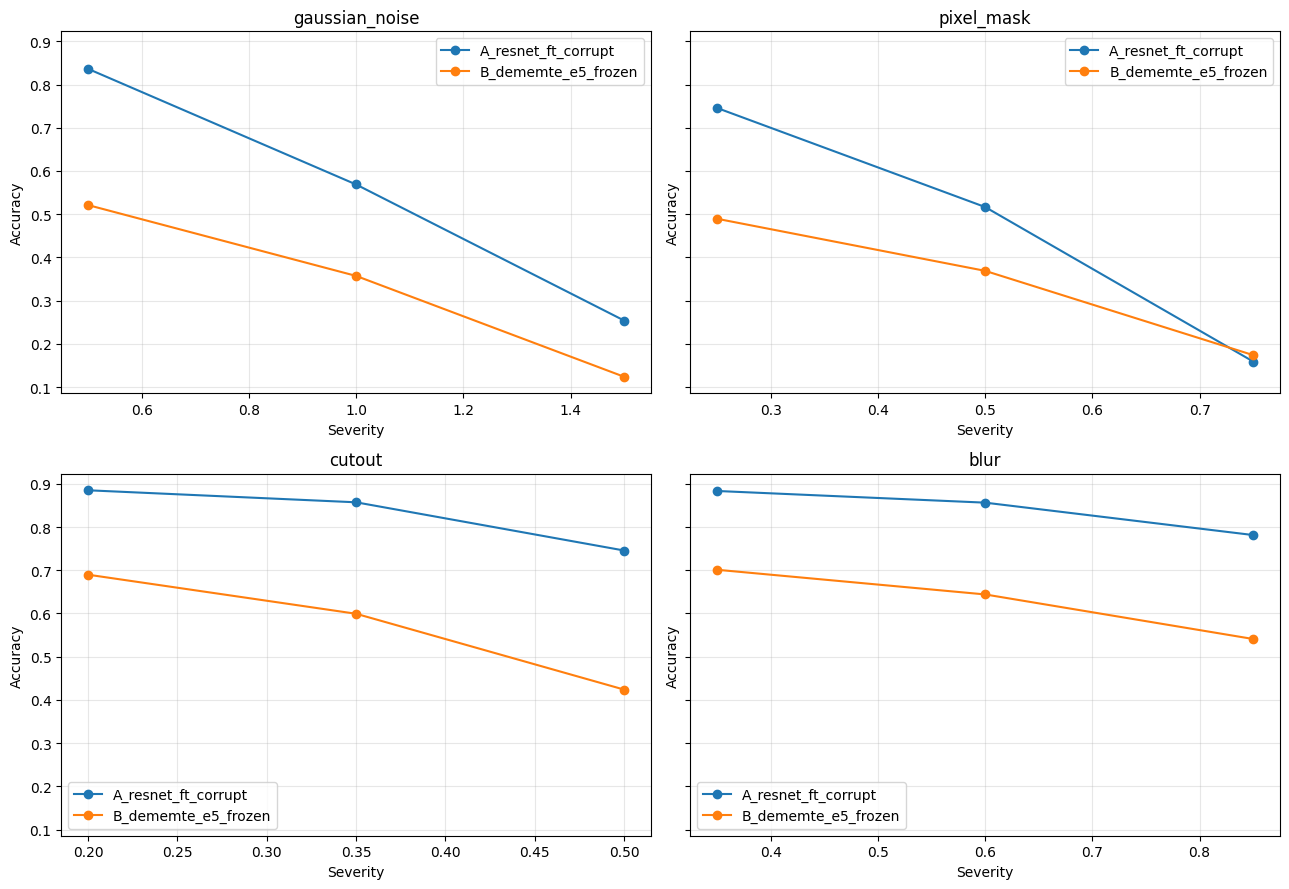

In [15]:
ft_curves = signal_curve_rows_baseline('A_resnet_ft_corrupt', ft_clean, ft_corr)
e5_curves = signal_curve_rows('B_dememte_e5_frozen', 'DeMemte E5', e5_clean, e5_corr)
all_curves = pd.DataFrame(ft_curves + e5_curves)
all_curves.to_csv(OUT / 'comparison_curves.csv', index=False)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
for ax, corr in zip(axes.flat, ['gaussian_noise', 'pixel_mask', 'cutout', 'blur']):
    for variant, sub in all_curves[all_curves['corruption'] == corr].groupby('variant'):
        ax.plot(sub['severity'], sub['acc'], marker='o', label=variant)
    ax.set_title(corr); ax.grid(alpha=0.3); ax.set_xlabel('Severity'); ax.set_ylabel('Accuracy'); ax.legend()
ensure_dir(OUT / 'plots')
fig.savefig(OUT / 'plots' / 'robustness_curves.png', dpi=120, bbox_inches='tight')
plt.tight_layout(); plt.show()

## Scatter clean vs corrupt — ¿se rompe el trade-off?

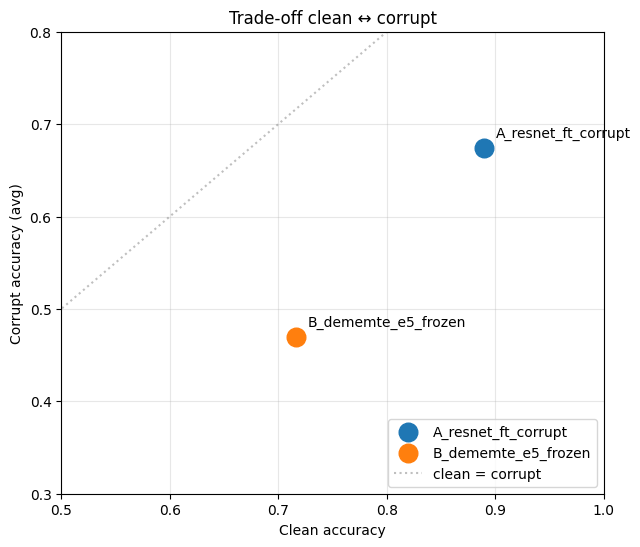

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
for _, row in comparison.iterrows():
    ax.scatter(row['clean_acc'], row['corrupt_acc_avg'], s=180, label=row['condition'])
    ax.annotate(row['condition'], (row['clean_acc'], row['corrupt_acc_avg']),
                xytext=(8, 8), textcoords='offset points', fontsize=10)
ax.plot([0, 1], [0, 1], linestyle=':', color='gray', alpha=0.5, label='clean = corrupt')
ax.set_xlabel('Clean accuracy'); ax.set_ylabel('Corrupt accuracy (avg)')
ax.set_title('Trade-off clean ↔ corrupt')
ax.set_xlim(0.5, 1.0); ax.set_ylim(0.3, 0.8)
ax.grid(alpha=0.3); ax.legend(loc='lower right')
fig.savefig(OUT / 'plots' / 'scatter_tradeoff.png', dpi=120, bbox_inches='tight')
plt.show()

## Narrativa final

Lee la columna `gap_clean_minus_corrupt` de la tabla:

- Condición A (FT con corrupciones): mide el trade-off estándar entre clean y corrupt al adaptar el baseline.
- Condición B (DeMemte VQSA frozen): mide si la fusión VQ + self-attention mantiene clean accuracy mientras mejora robustez.

El scatter visualiza esto: si B está arriba-y-a-la-derecha de A, la ruta VQSA aporta una frontera clean/corrupt mejor que el baseline aumentado.
